# AdventureWorks Analytics

This project analyzes AdventureWorks sales data using Python (Pandas) and Matplotlib.

## Objectives

- Analyze revenue and profit performance
- Identify top products, countries and categories
- Evaluate profit margins
- Analyze revenue and profit trends over time
- Generate business insights

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

## Data Loading

Load AdventureWorks datasets including sales, products, territories, categories and subcategories.

In [4]:
sales_2020 = pd.read_csv("AdventureWorks Sales Data 2020.csv")

In [5]:
sales_2021 = pd.read_csv("AdventureWorks Sales Data 2021.csv")

In [6]:
sales_2022 = pd.read_csv("AdventureWorks Sales Data 2022.csv")

## Data Preparation

Combine sales datasets, merge lookup tables and create business metrics such as Revenue, Cost and Profit.

In [7]:
sales = pd.concat([sales_2020, sales_2021, sales_2022],ignore_index=True)

In [8]:
product = pd.read_csv('AdventureWorks Product Lookup.csv')

In [9]:
product.info()

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             293 non-null    int64  
 1   ProductSubcategoryKey  293 non-null    int64  
 2   ProductSKU             293 non-null    str    
 3   ProductName            293 non-null    str    
 4   ModelName              293 non-null    str    
 5   ProductDescription     293 non-null    str    
 6   ProductColor           243 non-null    str    
 7   ProductSize            293 non-null    str    
 8   ProductStyle           293 non-null    str    
 9   ProductCost            293 non-null    float64
 10  ProductPrice           293 non-null    float64
dtypes: float64(2), int64(2), str(7)
memory usage: 25.3 KB


In [10]:
territory = pd.read_csv('AdventureWorks Territory Lookup.csv')

In [11]:
territory.shape

(10, 4)

In [12]:
sales_product = sales.merge(product, on='ProductKey', how='left')

In [13]:
sales_product.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity',
       'ProductSubcategoryKey', 'ProductSKU', 'ProductName', 'ModelName',
       'ProductDescription', 'ProductColor', 'ProductSize', 'ProductStyle',
       'ProductCost', 'ProductPrice'],
      dtype='str')

In [14]:
sales_product['Revenue'] = (sales_product['OrderQuantity']*sales_product['ProductPrice'])

In [15]:
sales_product['Cost'] = (sales_product['OrderQuantity'] * sales_product['ProductCost'])

In [16]:
sales_product['Profit'] = (sales_product['Revenue'] - sales_product['Cost'])

In [17]:
sales_product['Revenue'].mean()

np.float64(444.5381796970345)

In [18]:
sales_product['Revenue'].sum()

np.float64(24914586.819299996)

In [19]:
sales_product['ProductName'].nunique()

130

## Product Analysis

Analyze product performance by revenue and profit.

In [20]:
top_products_rev = (sales_product
     .groupby('ProductName')
    ['Revenue'].sum()
    .sort_values(ascending=False)
    .head(10))

In [21]:
top_products_rev.to_frame()

,Revenue
ProductName,
"Mountain-200 Black, 46",1.241754e+06
"Mountain-200 Black, 42",1.233557e+06
"Mountain-200 Silver, 38",1.213852e+06
"Mountain-200 Silver, 46",1.182781e+06
"Mountain-200 Black, 38",1.165937e+06
"Mountain-200 Silver, 42",1.133067e+06
"Road-250 Black, 52",6.893738e+05
"Road-250 Red, 58",6.610134e+05
"Road-250 Black, 48",6.413794e+05


In [22]:
top_products_rev_df = top_products_rev.to_frame()

In [23]:
top_products_rev_df

,Revenue
ProductName,
"Mountain-200 Black, 46",1.241754e+06
"Mountain-200 Black, 42",1.233557e+06
"Mountain-200 Silver, 38",1.213852e+06
"Mountain-200 Silver, 46",1.182781e+06
"Mountain-200 Black, 38",1.165937e+06
"Mountain-200 Silver, 42",1.133067e+06
"Road-250 Black, 52",6.893738e+05
"Road-250 Red, 58",6.610134e+05
"Road-250 Black, 48",6.413794e+05


In [24]:
top_products_profit = (sales_product
                      .groupby('ProductName')
                      ['Profit'].sum()
                      .sort_values(ascending=False)
                      .head(10))

In [25]:
top_products_profit

ProductName
Mountain-200 Black, 46     571632.6492
Mountain-200 Black, 42     567859.4964
Mountain-200 Silver, 38    558788.3282
Mountain-200 Silver, 46    544484.8727
Mountain-200 Black, 38     536730.9858
Mountain-200 Silver, 42    521599.3439
Road-250 Black, 52         272037.6692
Road-250 Red, 58           260846.2461
Road-250 Black, 48         253098.3378
Road-150 Red, 48           251848.6682
Name: Profit, dtype: float64

In [26]:
sales_territory = sales.merge (territory, left_on = 'TerritoryKey', right_on = 'SalesTerritoryKey', how='left')

In [27]:
sales_product_territ = sales_product.merge (territory, left_on = 'TerritoryKey', right_on = 'SalesTerritoryKey', how = 'left')

In [28]:
type(sales_product_territ)

pandas.DataFrame

## Country Analysis

Analyze revenue contribution by country and identify key markets.

In [29]:
top_countries_rev = (sales_product_territ
                     .groupby('Country')
                     ['Revenue'].sum()
                     .sort_values(ascending = False)
                     .head(10))

In [30]:
top_countries_rev

Country
United States     7.938999e+06
Australia         7.416456e+06
United Kingdom    2.902562e+06
Germany           2.524680e+06
France            2.362643e+06
Canada            1.769246e+06
Name: Revenue, dtype: float64

In [31]:
countries_rev = (sales_product_territ
                     .groupby('Country')
                     ['Revenue'].sum()
                     .sort_values(ascending = False))

In [32]:
total_rev = countries_rev.sum()

In [33]:
total_rev

np.float64(24914586.819300003)

In [34]:
country_rev_sharepct = (countries_rev / total_rev *100).round(2)

In [35]:
country_rev_sharepct

Country
United States     31.86
Australia         29.77
United Kingdom    11.65
Germany           10.13
France             9.48
Canada             7.10
Name: Revenue, dtype: float64

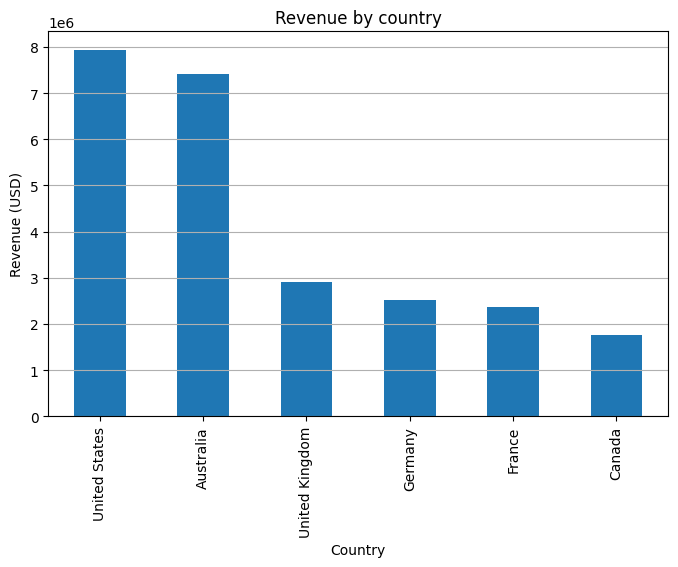

In [36]:
countries_rev.plot(kind = 'bar', figsize =(8,5))
plt.title ('Revenue by country')
plt.ylabel('Revenue (USD)')
plt.xlabel('Country')
plt.grid(axis='y')

### Key Insights

- United States generated the highest revenue (7.94M).
- Australia ranked second with 7.42M revenue.
- The top two countries contributed more than 60% of total revenue.
- Revenue in the United States was nearly three times higher than in the United Kingdom.

## Category Analysis

Analyze category revenue, profit and profit margin.

In [37]:
category = pd.read_csv('AdventureWorks Product Categories Lookup.csv')

In [38]:
subcategory = pd.read_csv('AdventureWorks Product Subcategories Lookup.csv')

In [39]:
sales_product_territ_sc = (
    sales_product_territ.merge (
        subcategory, 
        left_on = 'ProductSubcategoryKey', 
        right_on = 'ProductSubcategoryKey', 
        how = 'left'
    )
)

In [40]:
sales_product_territ_sc_c = (
    sales_product_territ_sc.merge (
        category, 
        left_on = 'ProductCategoryKey', 
        right_on = 'ProductCategoryKey', 
        how = 'left'
    )
)

In [41]:
sales_full = sales_product_territ_sc_c

In [42]:
sales_full.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity',
       'ProductSubcategoryKey', 'ProductSKU', 'ProductName', 'ModelName',
       'ProductDescription', 'ProductColor', 'ProductSize', 'ProductStyle',
       'ProductCost', 'ProductPrice', 'Revenue', 'Cost', 'Profit',
       'SalesTerritoryKey', 'Region', 'Country', 'Continent',
       'SubcategoryName', 'ProductCategoryKey', 'CategoryName'],
      dtype='str')

In [43]:
sales_full.isna().sum()

OrderDate                    0
StockDate                    0
OrderNumber                  0
ProductKey                   0
CustomerKey                  0
TerritoryKey                 0
OrderLineItem                0
OrderQuantity                0
ProductSubcategoryKey        0
ProductSKU                   0
ProductName                  0
ModelName                    0
ProductDescription           0
ProductColor             26878
ProductSize                  0
ProductStyle                 0
ProductCost                  0
ProductPrice                 0
Revenue                      0
Cost                         0
Profit                       0
SalesTerritoryKey            0
Region                       0
Country                      0
Continent                    0
SubcategoryName              0
ProductCategoryKey           0
CategoryName                 0
dtype: int64

### Data Quality Check

Missing values were checked after merging all tables.

No missing values were found in key analytical fields such as Revenue, Profit, Country, Region, Category and Product information.

Missing values were identified only in ProductColor, which is not used in the analysis and does not affect business conclusions.

In [44]:
category_rev = (sales_full
                     .groupby('CategoryName')
                     ['Revenue'].sum()
                     .sort_values(ascending = False))

In [45]:
category_rev

CategoryName
Bikes          2.364250e+07
Accessories    9.066731e+05
Clothing       3.654186e+05
Name: Revenue, dtype: float64

In [46]:
category_rev_m = category_rev/1000000

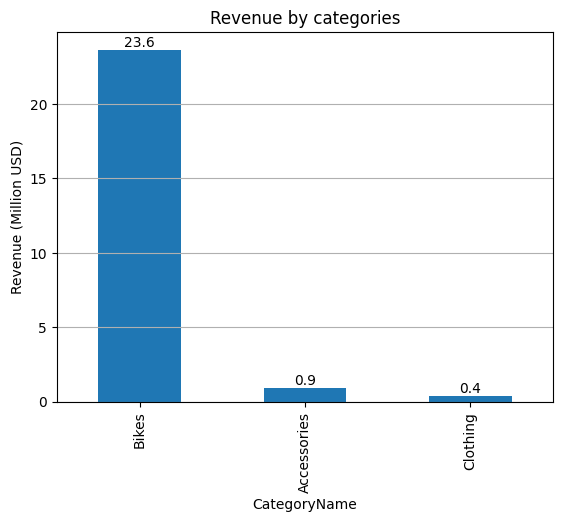

In [47]:
ax = category_rev_m.plot(kind='bar')
ax.bar_label(
    ax.containers[0],
    fmt='%.1f'
)

plt.title('Revenue by categories')
plt.ylabel ('Revenue (Million USD)')
plt.grid(axis='y')

### Key Insight
Bikes generated the vast majority of company revenue, accounting for more than 95% of total sales.

In [48]:
category['CategoryName']

0          Bikes
1     Components
2       Clothing
3    Accessories
Name: CategoryName, dtype: str

In [49]:
subcategory[
    subcategory['ProductCategoryKey'] == 2
]

,ProductSubcategoryKey,SubcategoryName,ProductCategoryKey
3,4,Handlebars,2
4,5,Bottom Brackets,2
5,6,Brakes,2
6,7,Chains,2
7,8,Cranksets,2
8,9,Derailleurs,2
9,10,Forks,2
10,11,Headsets,2
11,12,Mountain Frames,2
12,13,Pedals,2


In [50]:
sales_full[
    sales_full['CategoryName'] == 'Components'
]

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductSubcategoryKey,ProductSKU,...,Revenue,Cost,Profit,SalesTerritoryKey,Region,Country,Continent,SubcategoryName,ProductCategoryKey,CategoryName


### Components Category

No sales transactions were identified for the Components category during the analyzed period.

This indicates that Components products were not sold directly in the AdventureWorks dataset used for this analysis.

In [51]:
category_profit = (sales_full
                     .groupby('CategoryName')
                     ['Profit'].sum()
                     .sort_values(ascending = False))

In [52]:
category_profit

CategoryName
Bikes          9.726168e+06
Accessories    5.697601e+05
Clothing       1.617871e+05
Name: Profit, dtype: float64

In [53]:
category_margin = (category_profit/category_rev *100).round(2)

In [54]:
category_margin

CategoryName
Bikes          41.14
Accessories    62.84
Clothing       44.27
dtype: float64

Insight
- Bikes generated the highest revenue and profit.
- Accessories achieved the highest profit margin (62.84%).
- Despite lower sales volume, Accessories were the most profitable category relative to revenue.

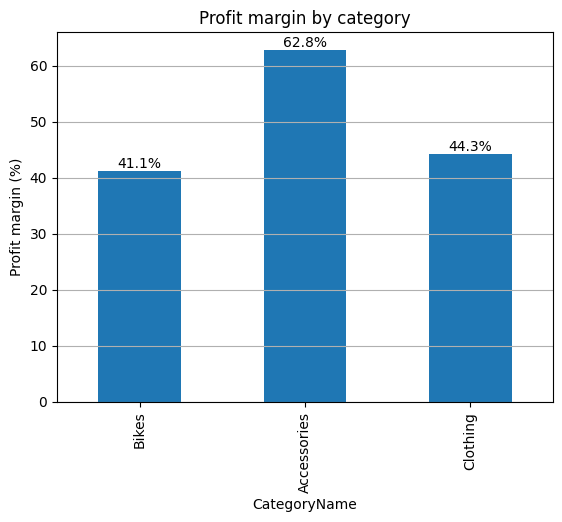

In [55]:
ax = category_margin.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt ='%.1f%%')

plt.title('Profit margin by category')
plt.ylabel('Profit margin (%)')
plt.grid(axis='y')

### Key Insight

Accessories achieved the highest profit margin (62.8%), despite generating significantly lower revenue than Bikes, which generated the majority of total revenue.

In [56]:
sales_full['OrderDate'] = pd.to_datetime(sales_full['OrderDate'])

In [57]:
sales_full['Month'] = sales_full['OrderDate'].dt.to_period('M')

In [58]:
sales_full['Month']

0        2020-01
1        2020-01
2        2020-01
3        2020-01
4        2020-01
          ...   
56041    2022-06
56042    2022-06
56043    2022-06
56044    2022-06
56045    2022-06
Name: Month, Length: 56046, dtype: period[M]

In [59]:
sales_full.head()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductSubcategoryKey,ProductSKU,...,Cost,Profit,SalesTerritoryKey,Region,Country,Continent,SubcategoryName,ProductCategoryKey,CategoryName,Month
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,2,BK-R50B-58,...,413.1463,285.9519,1,Northwest,United States,North America,Road Bikes,1,Bikes,2020-01
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,2,BK-R93R-48,...,2171.2942,1406.9758,4,Southwest,United States,North America,Road Bikes,1,Bikes,2020-01
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,1,BK-M82B-44,...,1898.0944,1476.8956,9,Australia,Australia,Pacific,Mountain Bikes,1,Bikes,2020-01
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,2,BK-R50B-44,...,413.1463,285.9519,6,Canada,Canada,North America,Road Bikes,1,Bikes,2020-01
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,2,BK-R93R-48,...,2171.2942,1406.9758,10,United Kingdom,United Kingdom,Europe,Road Bikes,1,Bikes,2020-01


## Time Analysis

Analyze revenue and profit trends over time.

In [60]:
monthly_revenue = (
    sales_full.
    groupby('Month')
    ['Revenue']
    .sum())

In [61]:
pd.options.display.float_format = '{:,.2f}'.format

In [62]:
monthly_revenue

Month
2020-01     585,312.65
2020-02     532,226.25
2020-03     643,436.10
2020-04     653,364.04
2020-05     659,325.90
2020-06     669,988.67
2020-07     486,115.01
2020-08     536,452.82
2020-09     344,062.87
2020-10     404,276.60
2020-11     326,611.15
2020-12     563,761.53
2021-01     432,425.74
2021-02     474,162.79
2021-03     471,961.88
2021-04     494,957.42
2021-05     545,534.74
2021-06     533,824.98
2021-07     815,356.47
2021-08     804,193.39
2021-09     952,743.49
2021-10   1,029,821.05
2021-11   1,133,913.05
2021-12   1,635,308.80
2022-01   1,274,378.67
2022-02   1,339,241.29
2022-03   1,448,596.12
2022-04   1,527,813.72
2022-05   1,768,432.51
2022-06   1,826,987.14
Freq: M, Name: Revenue, dtype: float64

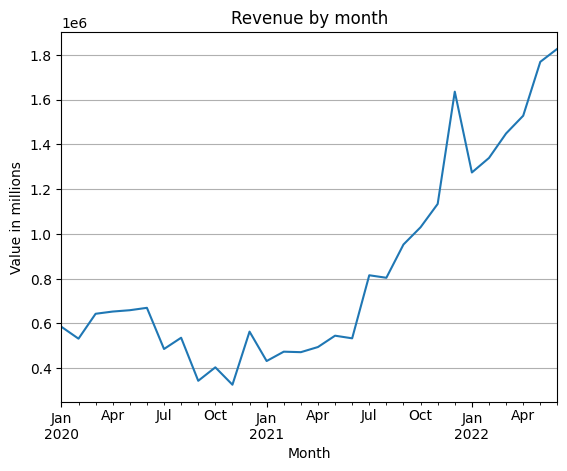

In [63]:
monthly_revenue.plot(kind ='line')
plt.title('Revenue by month')
plt.ylabel('Value in millions')
plt.grid(axis='y')

### Key Insights

- Revenue showed a strong upward trend from mid-2021 onward.
- Monthly revenue more than tripled between early 2020 and mid-2022.
- The highest revenue was recorded in June 2022.

In [64]:
monthly_profit = (
    sales_full.
    groupby('Month')
    ['Profit']
    .sum())

In [65]:
monthly_profit.head()

Month
2020-01   235,814.03
2020-02   212,186.69
2020-03   259,084.52
2020-04   263,031.34
2020-05   266,275.75
Freq: M, Name: Profit, dtype: float64

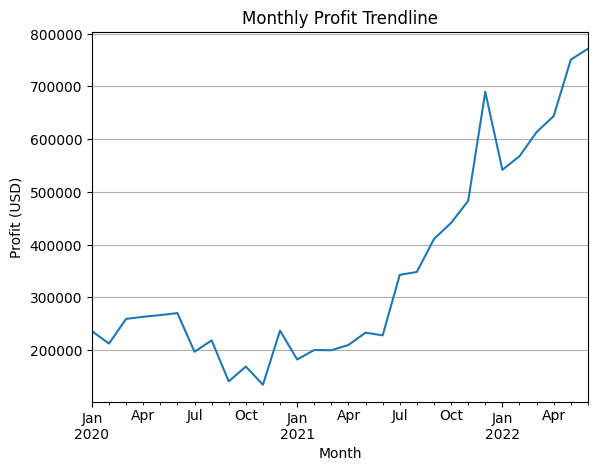

In [66]:
monthly_profit.plot(kind ='line')
plt.title('Monthly Profit Trendline')
plt.ylabel('Profit (USD)')
plt.grid(axis='y')

### Key Insights

Profit trend followed revenue very closely

## Business Insights

1. Bikes generated over 95% of total revenue.

2. Bikes generated the highest profit.

3. Accessories achieved the highest profit margin.

4. Revenue increased significantly after mid-2021.

5. Monthly revenue more than tripled between early 2020 and mid-2022.

6. Monthly profit followed a similar upward trend.

7. Components generated no sales during the analyzed period.

8. The business became increasingly dependent on bike sales.